# **Model #1 (Zoelie)**


---

**Inputs:** <br>
Window size: 1 second (512 samples) <br>
Window stride: 0.1 second (51 samples)<br>
Channels: all 16 <br>
Input shape: (16, 512)<br>

**Output:** <br>
Angle at window center <br>

**Model info:** <br>
Conv layers3: (filters: 32→64→128, kernels: 7→5→3)<br>
Pooling: MaxPool(4) after each conv <br>
FC layer: 1024→64→1<br>
Dropout: 0.5 <br>
Loss: MSE <br>
Optimizer: Adam (lr=0.001)<br>
Batch: size64 <br>
Split: 80/20 random <br>





In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv("../gait-data/train_set.csv")
labels_df = pd.read_csv("../gait-data/labels_train_set.csv")  # adjust filename as needed

# Merge EEG with labels
df = train_df.merge(labels_df, on='ID')

# Define EEG channels
eeg_channels = ['FP1', 'FP2', 'F3', 'F4', 'FC1', 'FC2', 'C4', 'C3',
                'Cz', 'CP2', 'CP1', 'P4', 'Pz', 'P3', 'O2', 'O1']

print(f"Data shape: {df.shape}")
print(f"Subjects: {df['Subject'].unique()}")
print(f"Sessions: {df['Session'].nunique()}")

Data shape: (3048430, 22)
Subjects: <StringArray>
['SCI2', 'SCI3']
Length: 2, dtype: str
Sessions: 15


In [4]:
def create_windows(df, window_size=512, stride=51, eeg_channels=eeg_channels):
    """
    Create 1-second windows (512 samples at 512Hz)
    stride=51 \u2248 0.1s to match test set structure
    """
    X_windows = []
    y_labels = []

    # Group by subject and session to avoid mixing
    for (subject, session), group in df.groupby(['Subject', 'Session']):
        eeg_data = group[eeg_channels].values  # (n_samples, 16)
        angles = group['angle'].values

        for start in range(0, len(group) - window_size, stride):
            end = start + window_size

            # EEG window: shape (16, 512)
            window = eeg_data[start:end].T

            # Label: angle at center of window (or end, your choice)
            label = angles[start + window_size // 2]

            X_windows.append(window)
            y_labels.append(label)

    return np.array(X_windows), np.array(y_labels)

# Create windows
X, y = create_windows(df)
print(f"Windows created: {X.shape}")  # should be (n_windows, 16, 512)
print(f"Labels shape: {y.shape}")

Windows created: (59540, 16, 512)
Labels shape: (59540,)


In [5]:
class EEGDataset(Dataset):
    def __init__(self, X, y, normalize=True):
        # Normalize per-channel
        if normalize:
            mean = X.mean(axis=(0, 2), keepdims=True)
            std = X.std(axis=(0, 2), keepdims=True)
            X = (X - mean) / (std + 1e-8)

        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Train/val split (by index for now — discuss session-based split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = EEGDataset(X_train, y_train)
val_dataset = EEGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [6]:
class EEGCNN(nn.Module):
    def __init__(self, n_channels=16, n_timepoints=512):
        super().__init__()

        # Temporal convolutions
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(4)
        self.dropout = nn.Dropout(0.5)

        # Calculate flattened size: 512 -> 128 -> 32 -> 8, with 128 channels
        self.fc1 = nn.Linear(128 * 8, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch, 16, 512)
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  # -> (batch, 32, 128)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))  # -> (batch, 64, 32)
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))  # -> (batch, 128, 8)

        x = x.flatten(1)  # -> (batch, 1024)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = EEGCNN()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 104,737


In [11]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [12]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        scheduler.step(val_loss)

        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    return history

# Train
history = train_model(model, train_loader, val_loader, epochs=50)

Epoch 0: Train Loss = 4911.4351, Val Loss = 4847.9114
Epoch 1: Train Loss = 4913.5468, Val Loss = 4847.8898
Epoch 2: Train Loss = 4916.5905, Val Loss = 4847.9061
Epoch 3: Train Loss = 4913.7812, Val Loss = 4847.9168
Epoch 4: Train Loss = 4911.2997, Val Loss = 4847.9301
Epoch 5: Train Loss = 4913.4360, Val Loss = 4847.9422
Epoch 6: Train Loss = 4911.8709, Val Loss = 4847.9518
Epoch 7: Train Loss = 4917.6349, Val Loss = 4847.9530
Epoch 8: Train Loss = 4926.8341, Val Loss = 4847.9549
Epoch 9: Train Loss = 4913.7589, Val Loss = 4847.9563
Epoch 10: Train Loss = 4912.4197, Val Loss = 4847.9574
Epoch 11: Train Loss = 4913.6383, Val Loss = 4847.9587
Epoch 12: Train Loss = 4911.0235, Val Loss = 4847.9598
Epoch 13: Train Loss = 4913.7175, Val Loss = 4847.9599
Epoch 14: Train Loss = 4911.8172, Val Loss = 4847.9600
Epoch 15: Train Loss = 4913.2626, Val Loss = 4847.9602
Epoch 16: Train Loss = 4910.8031, Val Loss = 4847.9603
Epoch 17: Train Loss = 4917.8836, Val Loss = 4847.9604
Epoch 18: Train Loss

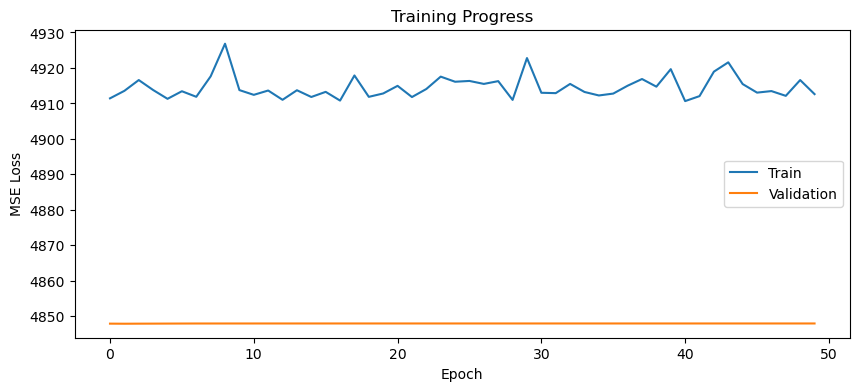

RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [14]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Predict on validation set and visualize
model.eval()

# Define 'device' again for this cell's scope
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    sample_X, sample_y = next(iter(val_loader))
    preds = model(sample_X.to(device)).numpy()

plt.figure(figsize=(12, 4))
plt.plot(sample_y[:100].numpy(), label='Actual', alpha=0.7)
plt.plot(preds[:100], label='Predicted', alpha=0.7)
plt.legend()
plt.title('Predicted vs Actual Angle')
plt.show()

Model #2 Lele

Model overview:



In [ ]:
import pandas as pd
import numpy as np

#Load CSVs

train_df = pd.read_csv('/content/train_set.csv')
labels_df = pd.read_csv('/content/labels_train_set.csv')

print("train_df shape :", train_df.shape)
print("labels_df shape:", labels_df.shape)
print("\ntrain_df columns:", list(train_df.columns[:]))
print("labels_df columns:", list(labels_df.columns))

train_df shape : (3048430, 20)
labels_df shape: (3048430, 3)

train_df columns: ['ID', 'Subject', 'Session', 'Time:512Hz', 'FP1', 'FP2', 'F3', 'F4', 'FC1', 'FC2', 'C4', 'C3', 'Cz', 'CP2', 'CP1', 'P4', 'Pz', 'P3', 'O2', 'O1']
labels_df columns: ['ID', 'time', 'angle']


In [ ]:
#Merge
train_df = train_df.rename(columns={"Time:512Hz": "time"})
merged_df = pd.merge(train_df, labels_df, on=["ID", "time"], how="inner")
print("Merged shape:", merged_df.shape)

Merged shape: (3048430, 21)


In [ ]:
motor_channels = ["FC1", "FC2", "C3", "C4", "Cz", "CP1", "CP2"]

In [ ]:
merged_df = merged_df.sort_values(["ID", "time"]).reset_index(drop=True)

#EEG Matrix (C, T)
eeg = merged_df[motor_channels].to_numpy(dtype=np.float32).T
#Angle vector(T,)
angle = merged_df["angle"].to_numpy(dtype=np.float32)

print("EEG shape:", eeg.shape)
print("Angle shape:", angle.shape)

EEG shape: (7, 3048430)
Angle shape: (3048430,)


In [ ]:
print(train_df["Session"].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [ ]:
all_sessions = sorted(merged_df["Session"].unique())

val_sessions = all_sessions[-3:]   # last 3
train_sessions = all_sessions[:-3]

train_df = merged_df[merged_df["Session"].isin(train_sessions)].copy()
val_df   = merged_df[merged_df["Session"].isin(val_sessions)].copy()

print("Train sessions:", train_sessions)
print("Val sessions:", val_sessions)
print("Train rows:", len(train_df))
print("Val rows:", len(val_df))

Train sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Val sessions: [np.int64(13), np.int64(14), np.int64(15)]
Train rows: 2367892
Val rows: 680538


In [ ]:
def extract_arrays_with_meta(df, channels):
    df = df.sort_values(["Session", "time"]).reset_index(drop=True)
    eeg = df[channels].to_numpy(dtype=np.float32).T
    ang = df["angle"].to_numpy(dtype=np.float32)
    time_arr = df["time"].to_numpy()
    session_arr = df["Session"].to_numpy()
    return eeg, ang, time_arr, session_arr

In [ ]:
def build_windows_by_session(df, channels, window_ms=500, stride_ms=200, delay_ms=0):
    X_all, y_all = [], []
    for _, g in df.groupby("Session"):
        g = g.sort_values("time")
        eeg = g[channels].to_numpy(np.float32).T
        ang = g["angle"].to_numpy(np.float32)
        Xg, yg = make_windows(eeg, ang, window_ms=window_ms, stride_ms=stride_ms, delay_ms=delay_ms)
        if len(yg) > 0:
            X_all.append(Xg); y_all.append(yg)
    return np.concatenate(X_all, axis=0), np.concatenate(y_all, axis=0)

X_train, y_train = build_windows_by_session(train_df, motor_channels, window_ms=500, stride_ms=50, delay_ms=0)
X_val,   y_val   = build_windows_by_session(val_df,   motor_channels, window_ms=500, stride_ms=50, delay_ms=0)

X_train = X_train[:, None, :, :]
X_val   = X_val[:, None, :, :]

print("X_train:", X_train.shape, "X_val:", X_val.shape)

X_train: (47241, 1, 7, 500) X_val: (13582, 1, 7, 500)


In [ ]:
# EEG normalization: per channel
mu = X_train.mean(axis=(0,3), keepdims=True)
sd = X_train.std(axis=(0,3), keepdims=True) + 1e-8
X_train = (X_train - mu) / sd
X_val   = (X_val   - mu) / sd

y_mu = y_train.mean()
y_sd = y_train.std() + 1e-8
y_train_n = (y_train - y_mu) / y_sd
y_val_n   = (y_val   - y_mu) / y_sd

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Convert numpy -> torch tensors
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train_n, dtype=torch.float32)

Xva = torch.tensor(X_val, dtype=torch.float32)
yva = torch.tensor(y_val_n, dtype=torch.float32)

print("Xtr:", Xtr.shape, "ytr:", ytr.shape)
print("Xva:", Xva.shape, "yva:", yva.shape)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=64, shuffle=False)

class SimpleEEGCNN(nn.Module):
    def __init__(self, n_channels=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 15), padding=(0, 7)),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),

            nn.Conv2d(16, 32, kernel_size=(1, 15), padding=(0, 7)),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),

            nn.Conv2d(32, 64, kernel_size=(n_channels, 1)),
            nn.BatchNorm2d(64),
            nn.ELU(),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1).squeeze(-1)

n_channels = X_train.shape[2]
model = SimpleEEGCNN(n_channels=n_channels).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
loss_fn = nn.MSELoss()
mae_fn = nn.L1Loss()

@torch.no_grad()
def eval_metrics():
    model.eval()
    total_mse, total_mae, n = 0.0, 0.0, 0

    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)

        total_mse += loss_fn(pred, yb).item() * xb.size(0)
        total_mae += mae_fn(pred, yb).item() * xb.size(0)
        n += xb.size(0)

    return total_mse / n, total_mae / n

best_val = float("inf")
best_state = None

for epoch in range(1, 16):
    model.train()
    total, n = 0.0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total += loss.item() * xb.size(0)
        n += xb.size(0)

    tr_mse = total / n
    va_mse, va_mae = eval_metrics()

    if va_mse < best_val:
        best_val = va_mse
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"epoch {epoch} | train MSE: {tr_mse:.4f} | val MSE: {va_mse:.4f} | val MAE: {va_mae:.4f}")

print("best val MSE:", best_val)

# restore best model
model.load_state_dict(best_state)
model.eval()

device: cpu
Xtr: torch.Size([47241, 1, 7, 500]) ytr: torch.Size([47241])
Xva: torch.Size([13582, 1, 7, 500]) yva: torch.Size([13582])


Model #3

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv('/content/sample_data/train_set.csv')
labels_df = pd.read_csv('/content/sample_data/labels_train_set.csv')  # adjust filename as needed

# Merge EEG with labels
df = train_df.merge(labels_df, on='ID')

eeg_channels = ['FP1', 'FP2', 'F3', 'F4', 'FC1', 'FC2', 'C4', 'C3',
                'Cz', 'CP2', 'CP1', 'P4', 'Pz', 'P3', 'O2', 'O1']

In [ ]:
def create_windows_with_lag(df, window_size=512, stride=51, lag_samples=51, eeg_channels=eeg_channels):
    """
    lag_samples: how many samples into the future the label is relative to the window.
    Example: if sampling rate is 512Hz, a lag of 51 samples is ~100ms.
    """
    X_windows = []
    y_labels = []

    for (subject, session), group in df.groupby(['Subject', 'Session']):
        eeg_data = group[eeg_channels].values
        angles = group['angle'].values

        # Adjusted range: we stop early enough to allow for the lag
        for start in range(0, len(group) - window_size - lag_samples, stride):
            end = start + window_size

            # EEG window stays the same
            window = eeg_data[start:end].T

            # Label is taken from the FUTURE (end of window + lag)
            # You can also use (start + window_size // 2) + lag_samples
            # if you prefer center-alignment
            label_idx = end + lag_samples
            label = angles[label_idx]

            X_windows.append(window)
            y_labels.append(label)

    return np.array(X_windows), np.array(y_labels)

In [ ]:
class EEGDataset(Dataset):
    def __init__(self, X, y, normalize=True):
        # Normalize per-channel
        if normalize:
            mean = X.mean(axis=(0, 2), keepdims=True)
            std = X.std(axis=(0, 2), keepdims=True)
            X = (X - mean) / (std + 1e-8)

        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Train/val split (by index for now — discuss session-based split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = EEGDataset(X_train, y_train)
val_dataset = EEGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

NameError: name 'X' is not defined

In [ ]:
class EEGCNN(nn.Module):
    def __init__(self, n_channels=16, n_timepoints=512):
        super().__init__()

        # Temporal convolutions
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(4)
        self.dropout = nn.Dropout(0.5)

        # Calculate flattened size: 512 -> 128 -> 32 -> 8, with 128 channels
        self.fc1 = nn.Linear(128 * 8, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (batch, 16, 512)
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))  # -> (batch, 32, 128)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))  # -> (batch, 64, 32)
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))  # -> (batch, 128, 8)

        x = x.flatten(1)  # -> (batch, 1024)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = EEGCNN()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 104,737


In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        scheduler.step(val_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    return history

# Train
history = train_model(model, train_loader, val_loader, epochs=50)

NameError: name 'train_loader' is not defined

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training Progress')
plt.show()

# Predict on validation set and visualize
model.eval()

# Define 'device' again for this cell's scope
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    sample_X, sample_y = next(iter(val_loader))
    preds = model(sample_X.to(device)).cpu().numpy()

plt.figure(figsize=(12, 4))
plt.plot(sample_y[:100].numpy(), label='Actual', alpha=0.7)
plt.plot(preds[:100], label='Predicted', alpha=0.7)
plt.legend()
plt.title('Predicted vs Actual Angle')
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x400 with 0 Axes>